# Notebook 1: The Protein Folding Problem

**Series:** AlphaFold2 from Scratch (1 of 8)

---

**Objective:** Understand the protein folding problem -- why it is hard, what the search space looks like, and the physical principles that constrain it.

---

**Prerequisites:** Linear algebra, basic thermodynamics, familiarity with Python/NumPy/Matplotlib.

**What we will cover:**
1. Amino acids and their chemical properties
2. The peptide bond and backbone geometry
3. Torsion angles ($\phi$, $\psi$, $\omega$) and how they define protein shape
4. The Ramachandran plot and steric constraints
5. Levinthal's paradox and the astronomical size of conformational space
6. Anfinsen's dogma and the energy landscape
7. Why AlphaFold2 changed everything

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, Arc
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})

print("Setup complete.")

Setup complete.


---
## 1. Amino Acids: The Building Blocks

Proteins are linear polymers of **amino acids**. There are 20 standard amino acids encoded by the genetic code, each with a common backbone and a unique side chain (R-group). The side chain determines the amino acid's chemical character -- whether it is polar, nonpolar, charged, or aromatic.

Every amino acid has the general structure:

$$
\text{H}_2\text{N} - \underset{|}{\overset{\text{R}}{\text{C}_\alpha\text{H}}} - \text{COOH}
$$

The 20 standard amino acids, their one-letter codes, and their physicochemical properties are listed below.

| Amino Acid | 3-Letter | 1-Letter | MW (Da) | Kyte-Doolittle | Category |
|:-----------|:--------:|:--------:|--------:|---------------:|:---------|
| Alanine | Ala | A | 89.1 | 1.8 | Nonpolar |
| Arginine | Arg | R | 174.2 | -4.5 | Positive |
| Asparagine | Asn | N | 132.1 | -3.5 | Polar |
| Aspartate | Asp | D | 133.1 | -3.5 | Negative |
| Cysteine | Cys | C | 121.2 | 2.5 | Nonpolar |
| Glutamate | Glu | E | 147.1 | -3.5 | Negative |
| Glutamine | Gln | Q | 146.2 | -3.5 | Polar |
| Glycine | Gly | G | 75.0 | -0.4 | Nonpolar |
| Histidine | His | H | 155.2 | -3.2 | Positive |
| Isoleucine | Ile | I | 131.2 | 4.5 | Nonpolar |
| Leucine | Leu | L | 131.2 | 3.8 | Nonpolar |
| Lysine | Lys | K | 146.2 | -3.9 | Positive |
| Methionine | Met | M | 149.2 | 1.9 | Nonpolar |
| Phenylalanine | Phe | F | 165.2 | 2.8 | Aromatic |
| Proline | Pro | P | 115.1 | -1.6 | Nonpolar |
| Serine | Ser | S | 105.1 | -0.8 | Polar |
| Threonine | Thr | T | 119.1 | -0.7 | Polar |
| Tryptophan | Trp | W | 204.2 | -0.9 | Aromatic |
| Tyrosine | Tyr | Y | 181.2 | -1.3 | Aromatic |
| Valine | Val | V | 117.1 | 4.2 | Nonpolar |

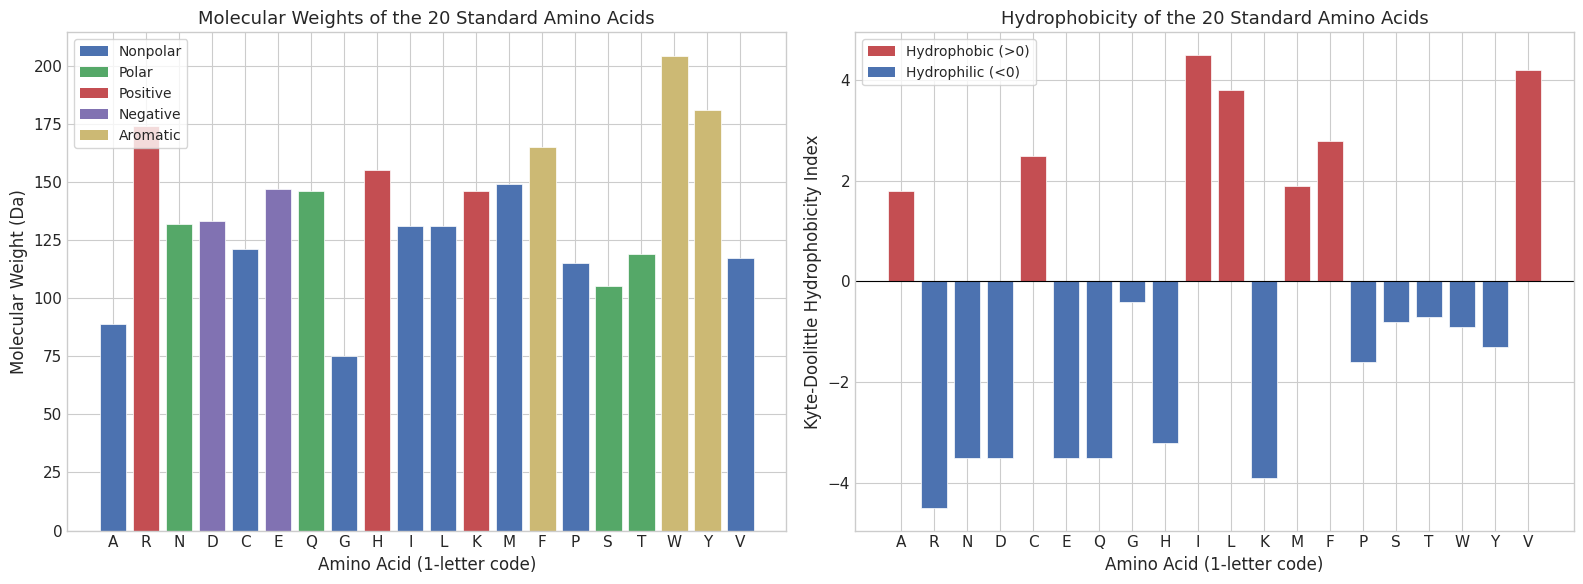

In [2]:
# Amino acid data: (1-letter code, molecular weight, Kyte-Doolittle hydrophobicity, category)
amino_acids = [
    ('A', 'Ala', 89.1,  1.8, 'Nonpolar'),
    ('R', 'Arg', 174.2, -4.5, 'Positive'),
    ('N', 'Asn', 132.1, -3.5, 'Polar'),
    ('D', 'Asp', 133.1, -3.5, 'Negative'),
    ('C', 'Cys', 121.2,  2.5, 'Nonpolar'),
    ('E', 'Glu', 147.1, -3.5, 'Negative'),
    ('Q', 'Gln', 146.2, -3.5, 'Polar'),
    ('G', 'Gly', 75.0,  -0.4, 'Nonpolar'),
    ('H', 'His', 155.2, -3.2, 'Positive'),
    ('I', 'Ile', 131.2,  4.5, 'Nonpolar'),
    ('L', 'Leu', 131.2,  3.8, 'Nonpolar'),
    ('K', 'Lys', 146.2, -3.9, 'Positive'),
    ('M', 'Met', 149.2,  1.9, 'Nonpolar'),
    ('F', 'Phe', 165.2,  2.8, 'Aromatic'),
    ('P', 'Pro', 115.1, -1.6, 'Nonpolar'),
    ('S', 'Ser', 105.1, -0.8, 'Polar'),
    ('T', 'Thr', 119.1, -0.7, 'Polar'),
    ('W', 'Trp', 204.2, -0.9, 'Aromatic'),
    ('Y', 'Tyr', 181.2, -1.3, 'Aromatic'),
    ('V', 'Val', 117.1,  4.2, 'Nonpolar'),
]

codes = [aa[0] for aa in amino_acids]
names = [aa[1] for aa in amino_acids]
mws = np.array([aa[2] for aa in amino_acids])
hydro = np.array([aa[3] for aa in amino_acids])
categories = [aa[4] for aa in amino_acids]

# Color map for categories
cat_colors = {
    'Nonpolar': '#4C72B0',
    'Polar':    '#55A868',
    'Positive': '#C44E52',
    'Negative': '#8172B2',
    'Aromatic': '#CCB974',
}
colors = [cat_colors[c] for c in categories]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Molecular weight bar chart ---
ax = axes[0]
bars = ax.bar(codes, mws, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Amino Acid (1-letter code)', fontsize=12)
ax.set_ylabel('Molecular Weight (Da)', fontsize=12)
ax.set_title('Molecular Weights of the 20 Standard Amino Acids', fontsize=13)
ax.tick_params(axis='both', labelsize=11)

# --- Hydrophobicity bar chart ---
ax = axes[1]
bar_colors = ['#C44E52' if h > 0 else '#4C72B0' for h in hydro]
ax.bar(codes, hydro, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Amino Acid (1-letter code)', fontsize=12)
ax.set_ylabel('Kyte-Doolittle Hydrophobicity Index', fontsize=12)
ax.set_title('Hydrophobicity of the 20 Standard Amino Acids', fontsize=13)
ax.tick_params(axis='both', labelsize=11)

# Add a legend for categories (left plot)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], label=c) for c in cat_colors]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=10, frameon=True)

# Add legend for hydrophobicity (right plot)
legend_elements2 = [
    Patch(facecolor='#C44E52', label='Hydrophobic (>0)'),
    Patch(facecolor='#4C72B0', label='Hydrophilic (<0)'),
]
axes[1].legend(handles=legend_elements2, loc='upper left', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

**Observations:**
- Glycine (G) is the smallest amino acid (MW = 75 Da); tryptophan (W) is the largest (MW = 204 Da).
- Isoleucine (I) and valine (V) are the most hydrophobic; arginine (R) and lysine (K) are the most hydrophilic.
- The hydrophobic effect -- the tendency of nonpolar residues to bury themselves away from water -- is the **dominant driving force** of protein folding.

---
## 2. The Peptide Bond and Backbone Geometry

Amino acids polymerize through **peptide bonds**: a condensation reaction between the carboxyl group of one amino acid and the amino group of the next, releasing water.

The protein backbone consists of a repeating pattern of three atoms per residue:

$$
\cdots - \text{N}_i - \text{C}^\alpha_i - \text{C}_i - \text{N}_{i+1} - \text{C}^\alpha_{i+1} - \text{C}_{i+1} - \cdots
$$

### Bond Lengths

The standard bond lengths are:

$$
d_{\text{N-C}^\alpha} = 1.46 \text{ A}, \quad d_{\text{C}^\alpha\text{-C}} = 1.52 \text{ A}, \quad d_{\text{C-N}} = 1.33 \text{ A}
$$

Note that the C-N peptide bond (1.33 A) is shorter than a typical C-N single bond (~1.47 A) due to **partial double-bond character** from resonance. This forces the six atoms of the peptide unit (C$^\alpha_i$, C$_i$, O$_i$, N$_{i+1}$, H$_{i+1}$, C$^\alpha_{i+1}$) into a **planar configuration**, with the dihedral angle $\omega \approx 180^\circ$ (trans) in almost all cases.

### Bond Angles

The bond angles are approximately:

$$
\angle(\text{N-C}^\alpha\text{-C}) \approx 111^\circ, \quad \angle(\text{C}^\alpha\text{-C-N}) \approx 116^\circ, \quad \angle(\text{C-N-C}^\alpha) \approx 121^\circ
$$

Since bond lengths and bond angles are essentially fixed by covalent chemistry, the **only remaining degrees of freedom** are the three backbone torsion angles per residue: $\phi$, $\psi$, and $\omega$.

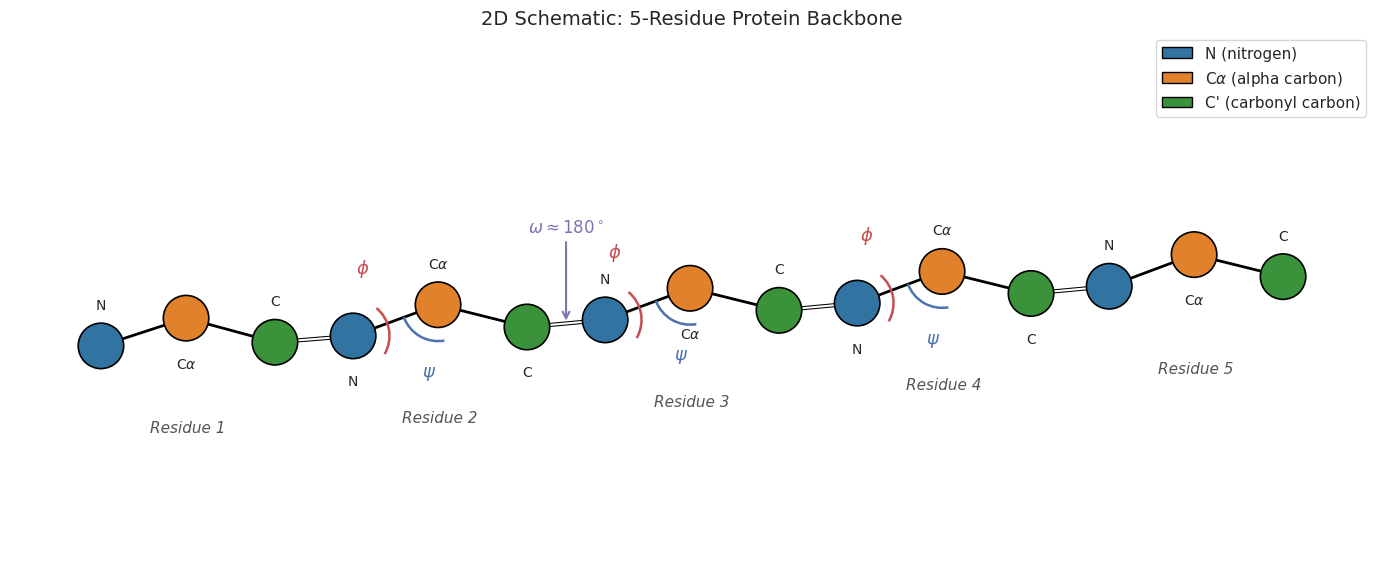

In [3]:
# 2D Schematic of a 5-residue backbone chain
# We draw a zig-zag backbone and label atoms, bonds, and torsion angles.

fig, ax = plt.subplots(figsize=(14, 7))

# Bond lengths (in plot units, scaled for visual clarity)
d_N_CA = 1.46
d_CA_C = 1.52
d_C_N  = 1.33

# Bond angles (radians) -- we use simplified angles for the 2D schematic
# We'll zig-zag the backbone by alternating directions
angle_up = np.radians(20)
angle_down = np.radians(-25)

# Build backbone positions manually for a nice zig-zag
# For 5 residues, we have 15 backbone atoms: N1, CA1, C1, N2, CA2, C2, ..., N5, CA5, C5
positions = []
atom_labels = []
residue_ids = []

x, y = 0.0, 3.0
angle = 0.0
bond_lengths = [d_N_CA, d_CA_C, d_C_N] * 5  # repeating pattern
atom_names = ['N', r'C$\alpha$', 'C'] * 5
res_ids = []
for i in range(5):
    res_ids.extend([i+1, i+1, i+1])

# Angles: alternate upward and downward to create a zig-zag
# The angles here are just for visual clarity, not physically accurate
angle_sequence = []
for i in range(15):
    if i % 3 == 0:   # N -> CA: slightly up
        angle_sequence.append(np.radians(15))
    elif i % 3 == 1: # CA -> C: down
        angle_sequence.append(np.radians(-20))
    else:            # C -> N: up
        angle_sequence.append(np.radians(10))

positions.append((x, y))
cumulative_angle = 0
for i in range(14):
    cumulative_angle += angle_sequence[i]
    # Dampen angle to keep chain mostly horizontal
    cumulative_angle *= 0.5
    dx = bond_lengths[i] * np.cos(cumulative_angle)
    dy = bond_lengths[i] * np.sin(cumulative_angle)
    x += dx * 1.1  # scale for visibility
    y += dy * 0.8
    positions.append((x, y))

positions = np.array(positions)

# Normalize to fit nicely
positions[:, 0] -= positions[:, 0].min()
positions[:, 0] = positions[:, 0] / positions[:, 0].max() * 13
positions[:, 0] += 0.5
positions[:, 1] -= positions[:, 1].mean()
positions[:, 1] = positions[:, 1] * 2 + 3.5

# Atom colors
atom_colors = {'N': '#3274A1', r'C$\alpha$': '#E1812C', 'C': '#3A923A'}

# Draw bonds
for i in range(14):
    x0, y0 = positions[i]
    x1, y1 = positions[i+1]
    # Peptide bond (C-N) gets a double-line to indicate partial double bond
    if i % 3 == 2:  # C -> N bond
        ax.plot([x0, x1], [y0, y1], 'k-', linewidth=3.0, zorder=1)
        ax.plot([x0, x1], [y0, y1], 'w-', linewidth=1.5, zorder=1)
    else:
        ax.plot([x0, x1], [y0, y1], 'k-', linewidth=2.0, zorder=1)

# Draw atoms
for i, (x, y) in enumerate(positions):
    name = atom_names[i]
    color = atom_colors[name]
    circle = plt.Circle((x, y), 0.25, color=color, ec='black', linewidth=1.2, zorder=3)
    ax.add_patch(circle)
    # Label above or below
    offset_y = 0.45 if i % 2 == 0 else -0.50
    ax.text(x, y + offset_y, name, ha='center', va='center', fontsize=10, zorder=4)

# Label residue numbers below
for res in range(1, 6):
    idx_start = (res - 1) * 3
    idx_end = idx_start + 2
    cx = (positions[idx_start, 0] + positions[idx_end, 0]) / 2
    cy = min(positions[idx_start, 1], positions[idx_end, 1]) - 0.9
    ax.text(cx, cy, f'Residue {res}', ha='center', va='center', fontsize=11,
            style='italic', color='#555555')

# Label torsion angles with arcs for residues 2, 3, 4
for res in [2, 3, 4]:
    idx_CA = (res - 1) * 3 + 1  # CA of this residue
    idx_N = (res - 1) * 3       # N of this residue
    idx_C = (res - 1) * 3 + 2   # C of this residue
    
    # phi angle at N (between C_{i-1}-N_i-CA_i-C_i)
    px, py = positions[idx_N]
    arc_phi = Arc((px, py), 0.8, 0.8, angle=0, theta1=-30, theta2=50,
                  color='#C44E52', linewidth=1.8, zorder=5)
    ax.add_patch(arc_phi)
    ax.text(px + 0.1, py + 0.75, r'$\phi$', fontsize=13, color='#C44E52',
            ha='center', va='center')
    
    # psi angle at CA (between N_i-CA_i-C_i-N_{i+1})
    px, py = positions[idx_CA]
    arc_psi = Arc((px, py), 0.8, 0.8, angle=0, theta1=200, theta2=280,
                  color='#4C72B0', linewidth=1.8, zorder=5)
    ax.add_patch(arc_psi)
    ax.text(px - 0.1, py - 0.75, r'$\psi$', fontsize=13, color='#4C72B0',
            ha='center', va='center')

# Label omega between residues 2 and 3
idx_C2 = 2 * 3 - 1  # C of residue 2
idx_N3 = 2 * 3       # N of residue 3
mx = (positions[idx_C2, 0] + positions[idx_N3, 0]) / 2
my = (positions[idx_C2, 1] + positions[idx_N3, 1]) / 2
ax.annotate(r'$\omega \approx 180^\circ$', xy=(mx, my), xytext=(mx, my + 1.0),
            fontsize=12, color='#8172B2', ha='center',
            arrowprops=dict(arrowstyle='->', color='#8172B2', lw=1.5))

# Bond length annotations
ax.annotate('', xy=(positions[3, 0], positions[3, 1] - 0.3),
            xytext=(positions[4, 0], positions[4, 1] - 0.3))

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor='#3274A1', edgecolor='black', label='N (nitrogen)'),
    Patch(facecolor='#E1812C', edgecolor='black', label=r'C$\alpha$ (alpha carbon)'),
    Patch(facecolor='#3A923A', edgecolor='black', label="C' (carbonyl carbon)"),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=11, frameon=True)

ax.set_xlim(-0.5, 14.5)
ax.set_ylim(0.5, 6.5)
ax.set_aspect('equal')
ax.set_title('2D Schematic: 5-Residue Protein Backbone', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.show()

The double-line segments between C and N represent the peptide bond with partial double-bond character. The torsion angles $\phi$ (red arcs around N) and $\psi$ (blue arcs around C$\alpha$) are the key degrees of freedom that determine protein conformation. The $\omega$ angle around the peptide bond is nearly always $180^\circ$ (trans configuration).

---
## 3. Torsion Angles: $\phi$, $\psi$, $\omega$

A **torsion angle** (dihedral angle) is the angle between two planes defined by four consecutive atoms $A$-$B$-$C$-$D$. It measures the rotation around the central bond $B$-$C$.

### Definitions

For residue $i$:

| Angle | Atoms | Rotation Around |
|:-----:|:-----:|:---------------:|
| $\phi_i$ | $\text{C}_{i-1}$ - $\text{N}_i$ - $\text{C}^\alpha_i$ - $\text{C}_i$ | N$_i$ - C$^\alpha_i$ bond |
| $\psi_i$ | $\text{N}_i$ - $\text{C}^\alpha_i$ - $\text{C}_i$ - $\text{N}_{i+1}$ | C$^\alpha_i$ - C$_i$ bond |
| $\omega_i$ | $\text{C}^\alpha_i$ - $\text{C}_i$ - $\text{N}_{i+1}$ - $\text{C}^\alpha_{i+1}$ | C$_i$ - N$_{i+1}$ peptide bond |

### Mathematical Formula

Given four consecutive atoms with positions $\mathbf{p}_1, \mathbf{p}_2, \mathbf{p}_3, \mathbf{p}_4$, the torsion angle $\theta$ is:

$$
\mathbf{b}_1 = \mathbf{p}_2 - \mathbf{p}_1, \quad \mathbf{b}_2 = \mathbf{p}_3 - \mathbf{p}_2, \quad \mathbf{b}_3 = \mathbf{p}_4 - \mathbf{p}_3
$$

$$
\mathbf{n}_1 = \mathbf{b}_1 \times \mathbf{b}_2, \quad \mathbf{n}_2 = \mathbf{b}_2 \times \mathbf{b}_3
$$

$$
\theta = \text{atan2}\!\left( (\mathbf{n}_1 \times \mathbf{n}_2) \cdot \hat{\mathbf{b}}_2, \; \mathbf{n}_1 \cdot \mathbf{n}_2 \right)
$$

where $\hat{\mathbf{b}}_2 = \mathbf{b}_2 / \|\mathbf{b}_2\|$. The range is $\theta \in (-180^\circ, 180^\circ]$.

### Why Do These Angles Matter?

Since bond lengths and bond angles are essentially rigid, the full 3D structure of the backbone is determined **entirely** by the sequence of $(\phi_i, \psi_i, \omega_i)$ angles. And since $\omega \approx 180^\circ$ in most cases, the backbone conformation is effectively a function of just two angles per residue:

$$
\text{3D structure} \;=\; f\!\left(\{\phi_i, \psi_i\}_{i=1}^{N}\right)
$$

Different combinations of $(\phi, \psi)$ give rise to different secondary structures:
- **Alpha helix:** $(\phi, \psi) \approx (-60^\circ, -45^\circ)$
- **Beta sheet:** $(\phi, \psi) \approx (-135^\circ, 135^\circ)$

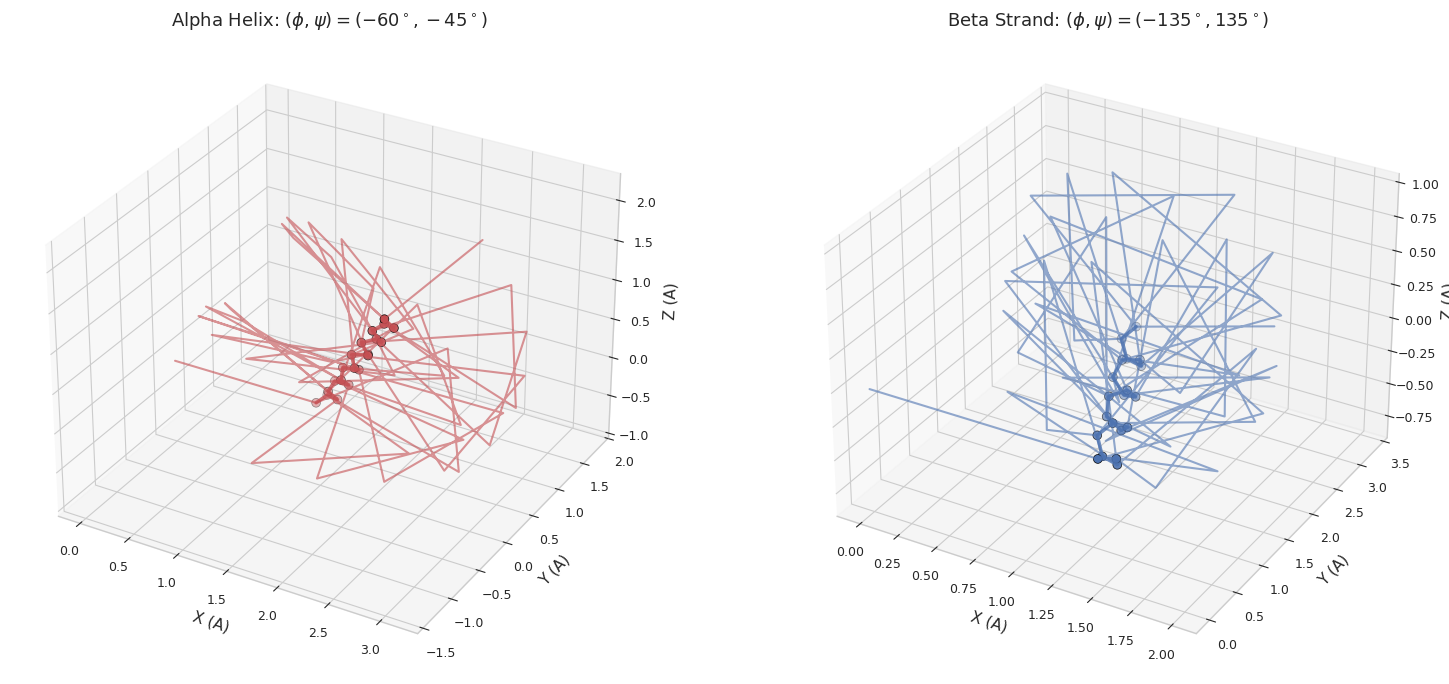

Alpha helix: 60 backbone atoms from 20 residues
Beta strand: 60 backbone atoms from 20 residues

Notice the characteristic helical twist of the alpha helix
versus the extended, nearly planar zig-zag of the beta strand.


In [4]:
def build_backbone(phi_psi_list, omega=np.radians(180.0)):
    """
    Build a 3D protein backbone from a list of (phi, psi) angle pairs (in radians).
    
    Uses standard bond lengths and bond angles:
      d(N-CA)  = 1.46 A
      d(CA-C)  = 1.52 A
      d(C-N)   = 1.33 A
      angle(C-N-CA)  = 121 deg
      angle(N-CA-C)  = 111 deg
      angle(CA-C-N)  = 116 deg
    
    Returns an Nx3 array of atom positions and list of atom names.
    """
    # Bond lengths
    d_N_CA = 1.46
    d_CA_C = 1.52
    d_C_N  = 1.33
    
    # Bond angles (radians)
    theta_C_N_CA  = np.radians(121.0)
    theta_N_CA_C  = np.radians(111.0)
    theta_CA_C_N  = np.radians(116.0)
    
    def place_atom(p1, p2, p3, bond_length, bond_angle, torsion):
        """Place a 4th atom given 3 previous atoms, bond length, angle, and torsion."""
        # Vectors
        v1 = p2 - p1
        v2 = p3 - p2
        
        # Normalize
        n = v2 / np.linalg.norm(v2)
        
        # Build local coordinate system
        # d is along -v2 direction
        d = -n
        
        # n_cross perpendicular to v1 and v2
        n_cross = np.cross(v1, v2)
        n_cross = n_cross / np.linalg.norm(n_cross)
        
        # m is perpendicular to d and n_cross
        m = np.cross(n_cross, d)
        
        # Spherical to Cartesian in local frame
        r_cos_theta = bond_length * np.cos(np.pi - bond_angle)
        r_sin_theta = bond_length * np.sin(np.pi - bond_angle)
        
        p4 = p3 + r_cos_theta * d + r_sin_theta * np.cos(torsion) * m + r_sin_theta * np.sin(torsion) * n_cross
        return p4
    
    # Initialize first three atoms (N, CA, C of residue 0)
    atoms = []
    atom_names = []
    
    # Place first N at origin
    N0 = np.array([0.0, 0.0, 0.0])
    # Place first CA along x
    CA0 = np.array([d_N_CA, 0.0, 0.0])
    # Place first C at proper angle
    C0 = CA0 + d_CA_C * np.array([np.cos(np.pi - theta_N_CA_C), np.sin(np.pi - theta_N_CA_C), 0.0])
    
    atoms.extend([N0, CA0, C0])
    atom_names.extend(['N', 'CA', 'C'])
    
    n_res = len(phi_psi_list)
    
    for i in range(n_res):
        phi_i, psi_i = phi_psi_list[i]
        
        if i == 0:
            # We already placed residue 0's N, CA, C.
            # Now we need to place the next N using psi of residue 0 and omega.
            # But first we need to compute psi: N-CA-C-N(+1)
            # Since phi of residue 0 has no C(-1), we skip applying phi for residue 0
            # Place N of next residue using psi_0
            if i < n_res - 1 or True:  # always place the next N
                N_next = place_atom(atoms[-3], atoms[-2], atoms[-1], d_C_N, theta_CA_C_N, psi_i)
                atoms.append(N_next)
                atom_names.append('N')
                
                # Place CA using omega
                CA_next = place_atom(atoms[-3], atoms[-2], atoms[-1], d_N_CA, theta_C_N_CA, omega)
                atoms.append(CA_next)
                atom_names.append('CA')
                
                # Place C using phi of next residue (will use next iteration's phi)
                if i + 1 < n_res:
                    phi_next = phi_psi_list[i + 1][0]
                else:
                    phi_next = phi_i  # repeat last
                C_next = place_atom(atoms[-3], atoms[-2], atoms[-1], d_CA_C, theta_N_CA_C, phi_next)
                atoms.append(C_next)
                atom_names.append('C')
        else:
            if i < n_res - 1:
                # Place N, CA, C for next residue
                N_next = place_atom(atoms[-3], atoms[-2], atoms[-1], d_C_N, theta_CA_C_N, psi_i)
                atoms.append(N_next)
                atom_names.append('N')
                
                CA_next = place_atom(atoms[-3], atoms[-2], atoms[-1], d_N_CA, theta_C_N_CA, omega)
                atoms.append(CA_next)
                atom_names.append('CA')
                
                if i + 1 < n_res:
                    phi_next = phi_psi_list[i + 1][0]
                else:
                    phi_next = phi_i
                C_next = place_atom(atoms[-3], atoms[-2], atoms[-1], d_CA_C, theta_N_CA_C, phi_next)
                atoms.append(C_next)
                atom_names.append('C')
    
    return np.array(atoms), atom_names


# Generate alpha helix backbone: (phi, psi) = (-60, -45)
n_residues = 20
alpha_angles = [(np.radians(-60), np.radians(-45))] * n_residues
alpha_coords, alpha_names = build_backbone(alpha_angles)

# Generate beta sheet backbone: (phi, psi) = (-135, 135)
beta_angles = [(np.radians(-135), np.radians(135))] * n_residues
beta_coords, beta_names = build_backbone(beta_angles)

# Plot both in 3D
fig = plt.figure(figsize=(16, 7))

# Alpha helix
ax1 = fig.add_subplot(121, projection='3d')
ca_mask = [n == 'CA' for n in alpha_names]
ca_coords = alpha_coords[ca_mask]

# Draw backbone
ax1.plot(alpha_coords[:, 0], alpha_coords[:, 1], alpha_coords[:, 2],
         '-', color='#C44E52', linewidth=1.5, alpha=0.6)
# Highlight CA atoms
ax1.scatter(ca_coords[:, 0], ca_coords[:, 1], ca_coords[:, 2],
            s=40, c='#C44E52', edgecolors='black', linewidth=0.5, zorder=5)
# Draw CA trace
ax1.plot(ca_coords[:, 0], ca_coords[:, 1], ca_coords[:, 2],
         '-', color='#C44E52', linewidth=2.5, alpha=0.8)

ax1.set_title(r'Alpha Helix: $(\phi, \psi) = (-60^\circ, -45^\circ)$', fontsize=13)
ax1.set_xlabel('X (A)', fontsize=11)
ax1.set_ylabel('Y (A)', fontsize=11)
ax1.set_zlabel('Z (A)', fontsize=11)
ax1.tick_params(labelsize=9)

# Beta sheet
ax2 = fig.add_subplot(122, projection='3d')
ca_mask_b = [n == 'CA' for n in beta_names]
ca_coords_b = beta_coords[ca_mask_b]

ax2.plot(beta_coords[:, 0], beta_coords[:, 1], beta_coords[:, 2],
         '-', color='#4C72B0', linewidth=1.5, alpha=0.6)
ax2.scatter(ca_coords_b[:, 0], ca_coords_b[:, 1], ca_coords_b[:, 2],
            s=40, c='#4C72B0', edgecolors='black', linewidth=0.5, zorder=5)
ax2.plot(ca_coords_b[:, 0], ca_coords_b[:, 1], ca_coords_b[:, 2],
         '-', color='#4C72B0', linewidth=2.5, alpha=0.8)

ax2.set_title(r'Beta Strand: $(\phi, \psi) = (-135^\circ, 135^\circ)$', fontsize=13)
ax2.set_xlabel('X (A)', fontsize=11)
ax2.set_ylabel('Y (A)', fontsize=11)
ax2.set_zlabel('Z (A)', fontsize=11)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print(f"Alpha helix: {len(alpha_coords)} backbone atoms from {n_residues} residues")
print(f"Beta strand: {len(beta_coords)} backbone atoms from {n_residues} residues")
print("\nNotice the characteristic helical twist of the alpha helix")
print("versus the extended, nearly planar zig-zag of the beta strand.")

**Key observations:**
- The **alpha helix** exhibits a characteristic right-handed helical twist. The helix has approximately 3.6 residues per turn and rises about 5.4 A per turn.
- The **beta strand** is extended and nearly planar, forming a zig-zag pattern. Beta strands associate laterally to form beta sheets via hydrogen bonds.
- These strikingly different 3D structures emerge from just two numbers per residue: $(\phi, \psi)$.

---
## 4. The Ramachandran Plot

Not all combinations of $(\phi, \psi)$ are physically realizable. Many angle pairs would cause **steric clashes** -- overlapping atomic van der Waals radii between non-bonded atoms.

G.N. Ramachandran, C. Ramakrishnan, and V. Sasisekharan (1963) calculated the allowed regions of $(\phi, \psi)$ space by computing steric overlap energies. The resulting **Ramachandran plot** is one of the most fundamental tools in structural biology.

### Steric Energy Model

We model the steric repulsion using a simplified Lennard-Jones-like potential. For two atoms separated by distance $r$ with van der Waals radii $r_0$:

$$
E_{\text{LJ}}(r) = \epsilon \left[ \left(\frac{r_0}{r}\right)^{12} - 2\left(\frac{r_0}{r}\right)^{6} \right]
$$

The $r^{-12}$ term dominates at short distances and creates a steep repulsive wall, while the $r^{-6}$ term provides weak van der Waals attraction. Steric clashes correspond to $r \ll r_0$, where the energy diverges.

For the Ramachandran plot, the critical contacts are between:
- The carbonyl oxygen O$_i$ and atoms of residue $i+1$
- The amide hydrogen H$_i$ and atoms of residue $i-1$
- Side-chain atoms (C$\beta$) and backbone atoms

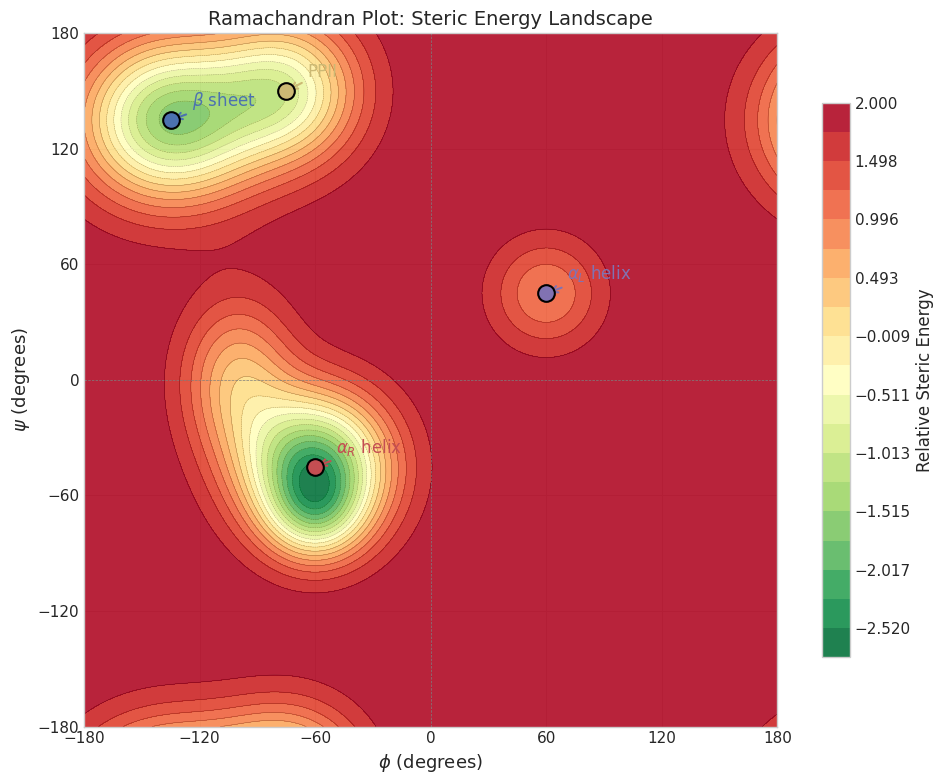

In [5]:
def compute_ramachandran_energy(phi_deg, psi_deg):
    """
    Compute a simplified steric energy for a given (phi, psi) pair.
    
    This is a phenomenological model that captures the main features
    of the Ramachandran plot without computing full atomic coordinates.
    We use Gaussian basins for allowed regions and a flat repulsive background.
    """
    phi = np.radians(phi_deg)
    psi = np.radians(psi_deg)
    
    # Define allowed regions as energy basins (Gaussian wells)
    # (center_phi, center_psi, sigma_phi, sigma_psi, depth)
    basins = [
        # Alpha-helix region (right-handed)
        (np.radians(-60), np.radians(-45), 0.45, 0.45, -4.0),
        # Beta-sheet region
        (np.radians(-135), np.radians(135), 0.55, 0.50, -3.5),
        # Left-handed helix (less favorable)
        (np.radians(60), np.radians(45), 0.35, 0.35, -1.0),
        # Polyproline II / extended
        (np.radians(-75), np.radians(150), 0.45, 0.45, -2.5),
        # Bridge region connecting alpha and beta
        (np.radians(-100), np.radians(0), 0.35, 0.50, -1.5),
        # pi helix region
        (np.radians(-60), np.radians(-70), 0.30, 0.30, -1.5),
    ]
    
    energy = 2.0  # repulsive background
    for phi0, psi0, sp, ss, depth in basins:
        # Use periodic distance on the torus
        dphi = np.arctan2(np.sin(phi - phi0), np.cos(phi - phi0))
        dpsi = np.arctan2(np.sin(psi - psi0), np.cos(psi - psi0))
        gauss = depth * np.exp(-0.5 * ((dphi / sp)**2 + (dpsi / ss)**2))
        energy += gauss
    
    return energy

# Vectorize the energy function
compute_energy_vec = np.vectorize(compute_ramachandran_energy)

# Create the Ramachandran energy landscape
phi_range = np.linspace(-180, 180, 300)
psi_range = np.linspace(-180, 180, 300)
PHI, PSI = np.meshgrid(phi_range, psi_range)
ENERGY = compute_energy_vec(PHI, PSI)

# --- Plot the Ramachandran map ---
fig, ax = plt.subplots(figsize=(10, 8))

# Contour plot of energy
levels = np.linspace(ENERGY.min(), 2.0, 20)
cf = ax.contourf(PHI, PSI, ENERGY, levels=levels, cmap='RdYlGn_r', alpha=0.9)
ax.contour(PHI, PSI, ENERGY, levels=levels, colors='black', linewidths=0.3, alpha=0.4)
cbar = plt.colorbar(cf, ax=ax, shrink=0.8, label='Relative Steric Energy')
cbar.ax.tick_params(labelsize=11)

# Mark key secondary structure regions
ss_regions = {
    r'$\alpha_R$ helix': (-60, -45, '#C44E52'),
    r'$\beta$ sheet': (-135, 135, '#4C72B0'),
    r'$\alpha_L$ helix': (60, 45, '#8172B2'),
    'PPII': (-75, 150, '#CCB974'),
}

for label, (phi_c, psi_c, color) in ss_regions.items():
    ax.plot(phi_c, psi_c, 'o', markersize=12, color=color, 
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    ax.annotate(label, (phi_c, psi_c), textcoords='offset points',
                xytext=(15, 10), fontsize=12, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

ax.set_xlabel(r'$\phi$ (degrees)', fontsize=13)
ax.set_ylabel(r'$\psi$ (degrees)', fontsize=13)
ax.set_title('Ramachandran Plot: Steric Energy Landscape', fontsize=14)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-180, 181, 60))
ax.tick_params(labelsize=11)
ax.set_aspect('equal')
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

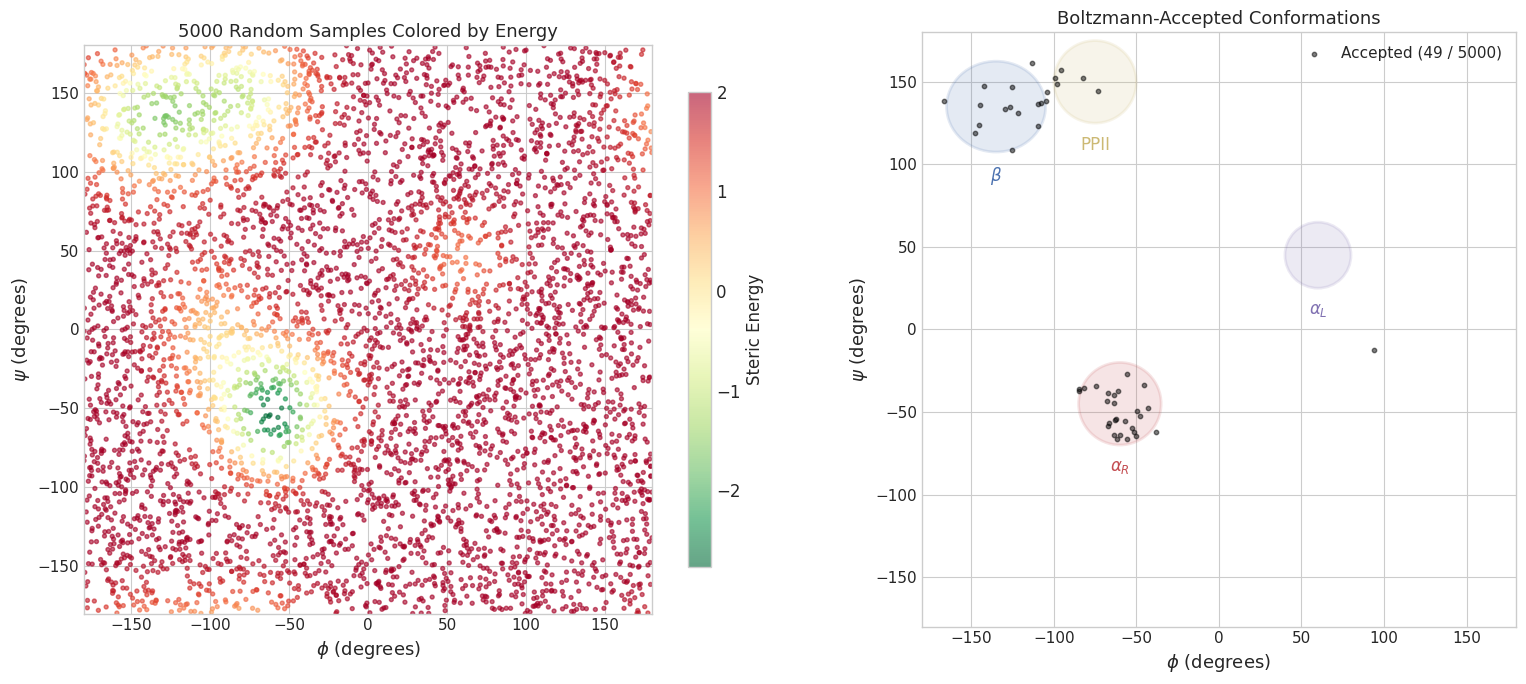

Of 5000 uniformly sampled (phi, psi) pairs, 49 (1.0%) are sterically allowed.
This illustrates that most of conformational space is FORBIDDEN by steric clashes.


In [6]:
# Scatter plot: sample random (phi, psi) angles, color by acceptance (Boltzmann weighting)
np.random.seed(42)
n_samples = 5000
phi_samples = np.random.uniform(-180, 180, n_samples)
psi_samples = np.random.uniform(-180, 180, n_samples)
energies = compute_energy_vec(phi_samples, psi_samples)

# Boltzmann weight: probability ~ exp(-E / kT), use kT ~ 0.6 for room temp scale
kT = 0.6
boltzmann_weights = np.exp(-energies / kT)
accept_prob = boltzmann_weights / boltzmann_weights.max()
accepted = np.random.random(n_samples) < accept_prob

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: all samples colored by energy
ax = axes[0]
sc = ax.scatter(phi_samples, psi_samples, c=energies, cmap='RdYlGn_r',
                s=8, alpha=0.6, vmin=ENERGY.min(), vmax=2.0)
plt.colorbar(sc, ax=ax, shrink=0.8, label='Steric Energy')
ax.set_xlabel(r'$\phi$ (degrees)', fontsize=13)
ax.set_ylabel(r'$\psi$ (degrees)', fontsize=13)
ax.set_title('5000 Random Samples Colored by Energy', fontsize=13)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_aspect('equal')
ax.tick_params(labelsize=11)

# Right: Boltzmann-accepted samples with secondary structure zones
ax = axes[1]

# Draw secondary structure regions as ellipses
from matplotlib.patches import Ellipse
ellipses = [
    (r'$\alpha_R$', -60, -45, 50, 50, '#C44E52', 0.15),
    (r'$\beta$', -135, 135, 60, 55, '#4C72B0', 0.15),
    (r'$\alpha_L$', 60, 45, 40, 40, '#8172B2', 0.15),
    ('PPII', -75, 150, 50, 50, '#CCB974', 0.15),
]
for label, cx, cy, w, h, color, alpha in ellipses:
    ell = Ellipse((cx, cy), w, h, facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
    ax.add_patch(ell)
    ax.text(cx, cy - h/2 - 8, label, ha='center', va='top', fontsize=12, color=color)

# Plot accepted samples
ax.scatter(phi_samples[accepted], psi_samples[accepted],
           s=10, c='black', alpha=0.5, label=f'Accepted ({accepted.sum()} / {n_samples})')

ax.set_xlabel(r'$\phi$ (degrees)', fontsize=13)
ax.set_ylabel(r'$\psi$ (degrees)', fontsize=13)
ax.set_title('Boltzmann-Accepted Conformations', fontsize=13)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_aspect('equal')
ax.legend(fontsize=11, loc='upper right')
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

print(f"Of {n_samples} uniformly sampled (phi, psi) pairs, {accepted.sum()} "
      f"({100*accepted.sum()/n_samples:.1f}%) are sterically allowed.")
print("This illustrates that most of conformational space is FORBIDDEN by steric clashes.")

**Key takeaways from the Ramachandran plot:**

1. Only about ~20-30% of $(\phi, \psi)$ space is sterically allowed for non-glycine residues.
2. The **right-handed alpha-helix** ($\alpha_R$) and **beta-sheet** ($\beta$) regions are the most favorable, explaining why these are the dominant secondary structures in nature.
3. The **left-handed helix** ($\alpha_L$) region is allowed but rare -- it is disfavored for L-amino acids.
4. **Glycine**, with no side chain (R = H), has a much larger allowed region. **Proline**, with a cyclic side chain constraining $\phi \approx -60^\circ$, has a very restricted region.

---
## 5. Levinthal's Paradox

Cyrus Levinthal (1969) posed a thought experiment that highlights the enormity of the protein folding problem.

### The Calculation

If we discretize the $(\phi, \psi)$ angles into just **3 rotameric states** each (e.g., gauche+, gauche-, trans), then each residue has $3 \times 3 = 9$ backbone conformations. For simplicity, Levinthal considered roughly 3 states per torsion angle.

For a protein with $N = 100$ residues, each having 2 relevant torsion angles ($\phi, \psi$), the total number of conformations is:

$$
\mathcal{C} = 3^{2N} = 3^{200} \approx 2.66 \times 10^{95}
$$

### The Time Problem

If the protein could sample one conformation per picosecond ($10^{-12}$ s), the time to exhaustively search all conformations would be:

$$
t = \frac{3^{200}}{10^{12} \text{ s}^{-1}} \approx \frac{10^{95}}{10^{12}} \text{ s} = 10^{83} \text{ s}
$$

For comparison, the age of the universe is approximately $4.3 \times 10^{17}$ s $\approx 10^{17.6}$ s.

$$
\frac{t}{t_{\text{universe}}} \approx \frac{10^{83}}{10^{17.6}} \approx 10^{65}
$$

Yet real proteins fold in **milliseconds to seconds**. This is **Levinthal's paradox**: proteins cannot fold by random search. There must be a directed mechanism -- a **funnel** in the energy landscape that guides folding toward the native state.

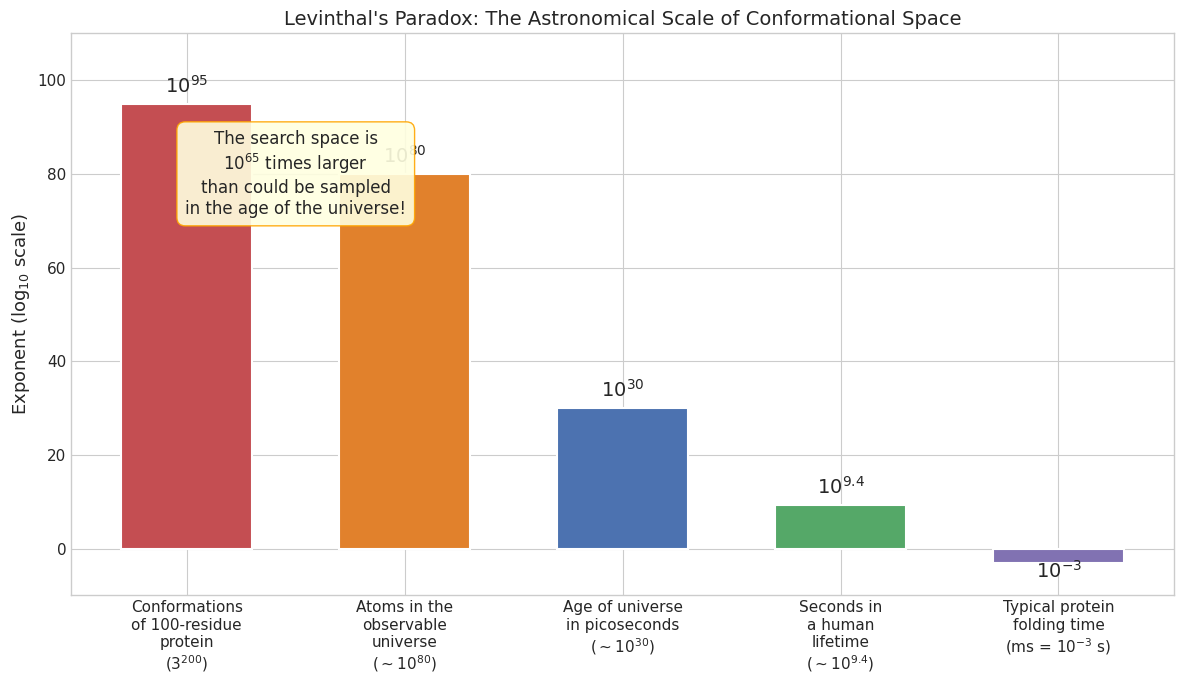

Number of conformations: 3^200 = 10^95.4
Atoms in observable universe: ~10^80
Age of universe: ~4.3 x 10^17 s = ~4.3 x 10^29 ps

Time to sample all conformations at 1/ps: 10^95.4 ps = 10^83.4 s
Ratio to age of universe: 10^65.8

Yet proteins fold in ~10^(-3) to 10^(0) seconds. How?


In [7]:
# Levinthal's paradox: log-scale comparison

# Values (log10)
labels = [
    'Conformations\nof 100-residue\nprotein\n($3^{200}$)',
    'Atoms in the\nobservable\nuniverse\n($\\sim 10^{80}$)',
    'Age of universe\nin picoseconds\n($\\sim 10^{30}$)',
    'Seconds in\na human\nlifetime\n($\\sim 10^{9.4}$)',
    'Typical protein\nfolding time\n(ms = $10^{-3}$ s)',
]
log_values = [
    95,    # 3^200 ~ 10^95
    80,    # atoms in universe
    30,    # age of universe in ps
    9.4,   # seconds in a lifetime
    -3,    # millisecond folding (in log10 seconds context, but we show as "comparison")
]
colors_bar = ['#C44E52', '#E1812C', '#4C72B0', '#55A868', '#8172B2']

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(range(len(labels)), log_values, color=colors_bar, 
              edgecolor='white', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar, val in zip(bars, log_values):
    y_pos = bar.get_height() + 1.5 if val > 0 else bar.get_height() - 4
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos, 
            f'$10^{{{val}}}$', ha='center', va='bottom', fontsize=14)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11, ha='center')
ax.set_ylabel('Exponent (log$_{10}$ scale)', fontsize=13)
ax.set_title("Levinthal's Paradox: The Astronomical Scale of Conformational Space", fontsize=14)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(-10, 110)

# Add annotation
ax.annotate('The search space is\n$10^{65}$ times larger\nthan could be sampled\nin the age of the universe!',
            xy=(0.5, 80), fontsize=12, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.show()

# Print exact calculation
import math
log10_conformations = 200 * math.log10(3)
print(f"Number of conformations: 3^200 = 10^{log10_conformations:.1f}")
print(f"Atoms in observable universe: ~10^80")
print(f"Age of universe: ~4.3 x 10^17 s = ~4.3 x 10^29 ps")
print(f"\nTime to sample all conformations at 1/ps: 10^{log10_conformations:.1f} ps = 10^{log10_conformations-12:.1f} s")
print(f"Ratio to age of universe: 10^{log10_conformations-12-17.6:.1f}")
print(f"\nYet proteins fold in ~10^(-3) to 10^(0) seconds. How?")

---
## 6. Anfinsen's Dogma and the Energy Landscape

### Anfinsen's Thermodynamic Hypothesis

In 1961, Christian Anfinsen demonstrated that denatured ribonuclease A could spontaneously refold to its native, catalytically active structure. This led to **Anfinsen's dogma** (Nobel Prize, 1972):

> The native structure of a small globular protein in its standard physiological environment is the **thermodynamically most stable** structure; it is uniquely determined by the amino acid sequence.

Formally, the native state $\mathbf{x}^*$ is the global minimum of the Gibbs free energy:

$$
\mathbf{x}^* = \arg\min_{\mathbf{x}} \; G(\mathbf{x}) = \arg\min_{\mathbf{x}} \; \left[ H(\mathbf{x}) - T S(\mathbf{x}) \right]
$$

where $H$ is the enthalpy (dominated by van der Waals, electrostatic, and hydrogen bonding interactions), $S$ is the entropy (conformational + solvent), and $T$ is the temperature.

### The Energy Funnel

The resolution of Levinthal's paradox lies in the shape of the energy landscape. Rather than a flat, featureless hypersurface (which would require random search), the true landscape is a **funnel**: a rough surface with a strong overall gradient toward the native state.

$$
G(\mathbf{x}) \sim G_0 + \alpha \, d(\mathbf{x}, \mathbf{x}^*)^2 + \text{roughness}
$$

where $d(\mathbf{x}, \mathbf{x}^*)$ is some distance metric to the native state. The funnel shape means that:
1. **Most random perturbations from the native state increase energy** (funnel walls).
2. **There is a persistent downhill bias** toward the native state.
3. **Local minima** (kinetic traps) exist but are shallow compared to the global funnel depth.

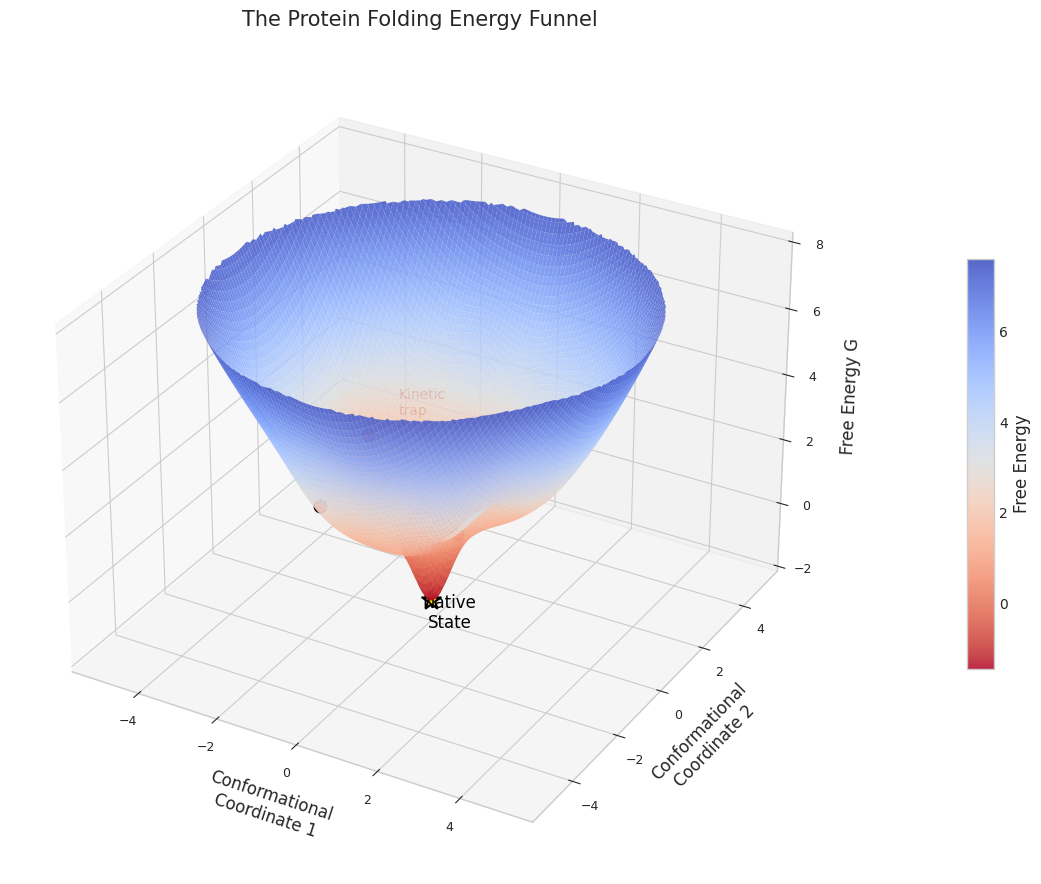

The funnel shape resolves Levinthal's paradox:
  - The protein does NOT search randomly through all conformations.
  - Instead, the energy landscape has a strong bias toward the native state.
  - The roughness creates kinetic traps, but the overall funnel guides folding.
  - Folding is a directed process, not a random walk.


In [8]:
# 3D surface plot: energy funnel landscape

# Create a funnel-shaped energy landscape
x = np.linspace(-5, 5, 300)
y = np.linspace(-5, 5, 300)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# Base funnel: quadratic bowl
Z_funnel = 0.3 * R**2

# Add roughness: small bumps
np.random.seed(123)
Z_rough = np.zeros_like(X)
# Gaussian bumps for local minima
n_bumps = 15
for _ in range(n_bumps):
    bx = np.random.uniform(-4, 4)
    by = np.random.uniform(-4, 4)
    bh = np.random.uniform(0.3, 1.5) * (0.3 + 0.7 * np.sqrt(bx**2 + by**2) / 5)  # bigger bumps farther out
    bw = np.random.uniform(0.4, 0.8)
    Z_rough += bh * np.exp(-((X - bx)**2 + (Y - by)**2) / (2 * bw**2))

# Add a few deeper local minima (kinetic traps)
traps = [(-2.5, 1.5, -0.8, 0.5), (1.8, -2.0, -0.6, 0.5), (-1.0, -3.0, -0.5, 0.6)]
for tx, ty, td, tw in traps:
    Z_rough += td * np.exp(-((X - tx)**2 + (Y - ty)**2) / (2 * tw**2))

# Deepen the global minimum
Z_native = -2.0 * np.exp(-(X**2 + Y**2) / (2 * 0.4**2))

Z = Z_funnel + Z_rough + Z_native

# Clip the outer edge for aesthetics
mask = R > 5.0
Z[mask] = np.nan

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm_r', alpha=0.85,
                       linewidth=0, antialiased=True,
                       rstride=3, cstride=3)

# Mark the global minimum
ax.scatter([0], [0], [Z[150, 150]], color='gold', s=200, edgecolors='black',
           linewidth=1.5, zorder=10, marker='*')
ax.text(0.3, 0.3, Z[150, 150] - 1.0, 'Native\nState', fontsize=12, color='black',
        ha='center')

# Mark kinetic traps
for i, (tx, ty, td, tw) in enumerate(traps):
    ix = int((tx + 5) / 10 * 299)
    iy = int((ty + 5) / 10 * 299)
    if 0 <= ix < 300 and 0 <= iy < 300:
        ax.scatter([tx], [ty], [Z[iy, ix]], color='red', s=80, 
                   edgecolors='black', linewidth=1, zorder=10, marker='o')
        if i == 0:
            ax.text(tx + 0.5, ty + 0.5, Z[iy, ix] + 0.5, 'Kinetic\ntrap',
                    fontsize=10, color='#C44E52')

# Labels
ax.set_xlabel('Conformational\nCoordinate 1', fontsize=12, labelpad=10)
ax.set_ylabel('Conformational\nCoordinate 2', fontsize=12, labelpad=10)
ax.set_zlabel('Free Energy G', fontsize=12, labelpad=8)
ax.set_title('The Protein Folding Energy Funnel', fontsize=15, pad=20)

# Set viewing angle
ax.view_init(elev=30, azim=-60)
ax.tick_params(labelsize=9)

# Add colorbar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, label='Free Energy', pad=0.1)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

print("The funnel shape resolves Levinthal's paradox:")
print("  - The protein does NOT search randomly through all conformations.")
print("  - Instead, the energy landscape has a strong bias toward the native state.")
print("  - The roughness creates kinetic traps, but the overall funnel guides folding.")
print("  - Folding is a directed process, not a random walk.")

### The Driving Forces of Folding

The free energy funnel arises from the interplay of several physical forces:

| Force | Contribution | Scale |
|:------|:-------------|:------|
| **Hydrophobic effect** | Nonpolar side chains bury away from water | Dominant driving force (~dominant $\Delta G$) |
| **Hydrogen bonds** | N-H$\cdots$O=C backbone; side chain H-bonds | Stabilize secondary structure |
| **Van der Waals** | Close packing of atoms in the protein interior | Tight packing of native state |
| **Electrostatic** | Salt bridges, charge-charge interactions | Long-range; can be stabilizing or destabilizing |
| **Conformational entropy** | Loss of backbone/side-chain degrees of freedom upon folding | Opposes folding ($-T\Delta S > 0$) |

The net stability of a folded protein is remarkably small:

$$
\Delta G_{\text{folding}} \approx -5 \text{ to } -15 \text{ kcal/mol}
$$

This is equivalent to just a few hydrogen bonds -- the folded state is only **marginally stable**, a balance of large opposing terms.

---
## 7. Why AlphaFold2 Changed Everything

For decades, the protein folding problem was considered one of the grand challenges of biology. Two distinct approaches were pursued:

1. **Physics-based methods**: Molecular dynamics simulations that integrate Newton's equations of motion. Accurate but computationally prohibitive for large proteins (the longest simulations cover milliseconds for small proteins).

2. **Knowledge-based methods**: Use known protein structures as templates (homology modeling) or statistical potentials from the PDB.

### The CASP Competition

The **Critical Assessment of protein Structure Prediction (CASP)** competition, held every two years since 1994, serves as the blind benchmark for structure prediction methods.

| Year | CASP | Milestone |
|:----:|:----:|:----------|
| 1994 | CASP1 | First competition; homology modeling dominates |
| 2006 | CASP7 | Fragment-based methods (Rosetta) advance |
| 2016 | CASP12 | First use of deep learning for contact prediction |
| 2018 | CASP13 | AlphaFold1 (DeepMind) wins with deep learning + potentials |
| **2020** | **CASP14** | **AlphaFold2 achieves near-experimental accuracy (GDT ~92)** |

### The Key Insight of AlphaFold2

AlphaFold2 bypasses physics simulation entirely. Its key insight is that **evolution has already solved the folding problem** -- the information is encoded in **multiple sequence alignments (MSAs)**.

When two residues are in spatial contact, mutations at one position are correlated with compensatory mutations at the other (to maintain the contact). This phenomenon is called **co-evolution**, and it encodes 3D contact information in 1D sequences:

$$
\text{Co-evolution}_{ij} \propto \text{Spatial proximity}_{ij}
$$

AlphaFold2's architecture:
1. **Evoformer**: processes MSAs and pair representations with attention mechanisms
2. **Structure Module**: iteratively refines 3D coordinates using invariant point attention
3. **Recycling**: feeds predictions back through the network for iterative refinement

We will build each of these components from scratch in the subsequent notebooks of this series.

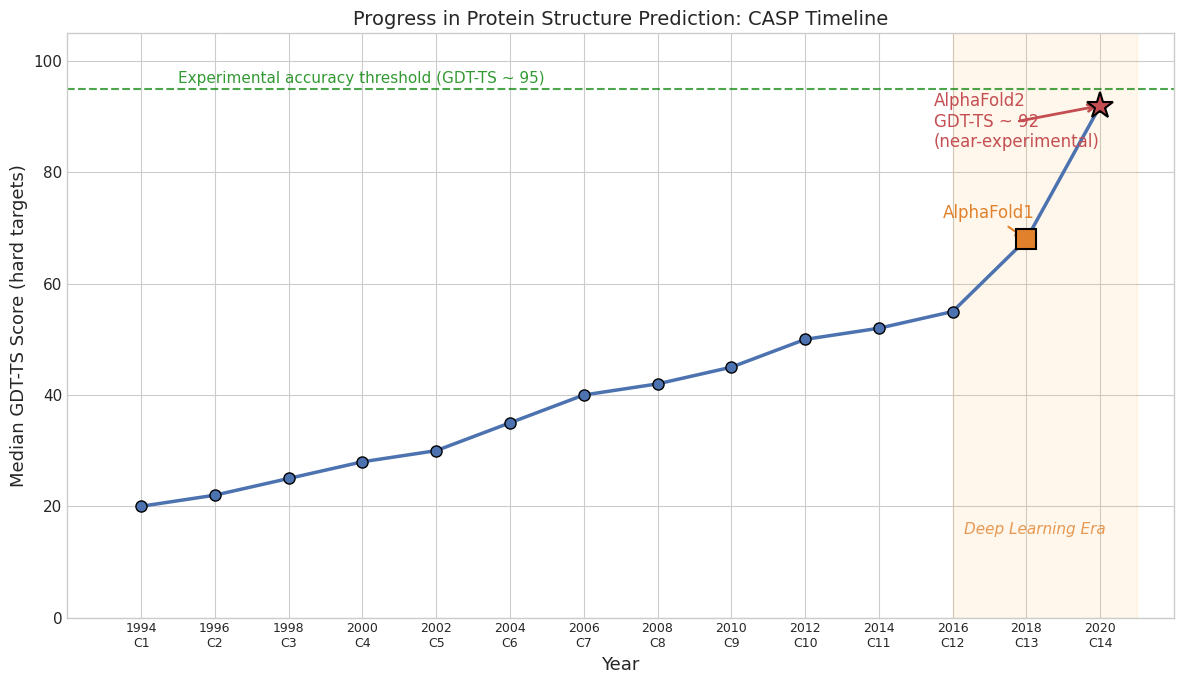

AlphaFold2 represented a quantum leap in prediction accuracy,
effectively solving the structure prediction problem for most single-domain proteins.


In [9]:
# CASP GDT-TS scores timeline (approximate median scores for best groups)

years = [1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020]
casp_nums = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']
# Approximate median GDT-TS for the best group on free-modeling (hard) targets
gdt_scores = [20, 22, 25, 28, 30, 35, 40, 42, 45, 50, 52, 55, 68, 92]

fig, ax = plt.subplots(figsize=(12, 7))

# Plot scores
ax.plot(years, gdt_scores, 'o-', color='#4C72B0', linewidth=2.5, markersize=8,
        markeredgecolor='black', markeredgewidth=1)

# Highlight AlphaFold entries
ax.plot(2018, 68, 's', color='#E1812C', markersize=14, markeredgecolor='black',
        markeredgewidth=1.5, zorder=10)
ax.annotate('AlphaFold1', (2018, 68), textcoords='offset points',
            xytext=(-60, 15), fontsize=12, color='#E1812C',
            arrowprops=dict(arrowstyle='->', color='#E1812C', lw=1.5))

ax.plot(2020, 92, '*', color='#C44E52', markersize=20, markeredgecolor='black',
        markeredgewidth=1.5, zorder=10)
ax.annotate('AlphaFold2\nGDT-TS ~ 92\n(near-experimental)', (2020, 92),
            textcoords='offset points', xytext=(-120, -30), fontsize=12, color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52', lw=2))

# Add horizontal line for "experimental accuracy"
ax.axhline(y=95, color='green', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(1995, 96, 'Experimental accuracy threshold (GDT-TS ~ 95)', fontsize=11,
        color='green', alpha=0.8)

# Shade the "deep learning era"
ax.axvspan(2016, 2021, alpha=0.08, color='orange')
ax.text(2016.3, 15, 'Deep Learning Era', fontsize=11, color='#E1812C',
        style='italic', alpha=0.8)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Median GDT-TS Score (hard targets)', fontsize=13)
ax.set_title('Progress in Protein Structure Prediction: CASP Timeline', fontsize=14)
ax.set_xlim(1992, 2022)
ax.set_ylim(0, 105)
ax.set_xticks(years)
ax.set_xticklabels([f"{y}\n{c}" for y, c in zip(years, casp_nums)], fontsize=9, rotation=0)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

print("AlphaFold2 represented a quantum leap in prediction accuracy,")
print("effectively solving the structure prediction problem for most single-domain proteins.")

---
## 8. Summary and Key Takeaways

In this notebook, we covered the fundamental concepts underlying the protein folding problem:

- **Amino acids** are the 20 building blocks of proteins, each with distinct physicochemical properties (hydrophobicity, charge, aromaticity) that govern how the protein folds.

- **The protein backbone** is a chain of repeating N-C$\alpha$-C units connected by peptide bonds with fixed bond lengths and angles. The backbone geometry is fully determined by the torsion angles $(\phi, \psi, \omega)$.

- **Torsion angles** $\phi$ and $\psi$ are the two key degrees of freedom per residue. The angle $\omega$ is nearly always $180^\circ$ (trans peptide bond).

- **The Ramachandran plot** reveals that most of $(\phi, \psi)$ space is sterically forbidden. The allowed regions correspond to the secondary structures we observe: alpha helices and beta sheets.

- **Levinthal's paradox** demonstrates that the conformational space for even a modest protein ($3^{200} \approx 10^{95}$ states for 100 residues) is astronomically large -- far too large for random search.

- **Anfinsen's dogma** states that the native structure is the global free energy minimum, and the **energy funnel** model explains how proteins can find this minimum without exhaustive search.

- **AlphaFold2** bypassed physics-based approaches entirely, using deep learning on evolutionary data (MSAs) to predict structures with near-experimental accuracy.

---

### Preview: Notebook 2 -- Multiple Sequence Alignments and Evolutionary Information

In the next notebook, we will dive into **multiple sequence alignments (MSAs)** -- the key input to AlphaFold2. We will cover:
- How to construct and interpret MSAs
- Sequence conservation and entropy
- Co-evolutionary analysis: mutual information and direct coupling analysis (DCA)
- How co-evolution encodes 3D contact information
- Building a simple contact prediction model from MSA statistics

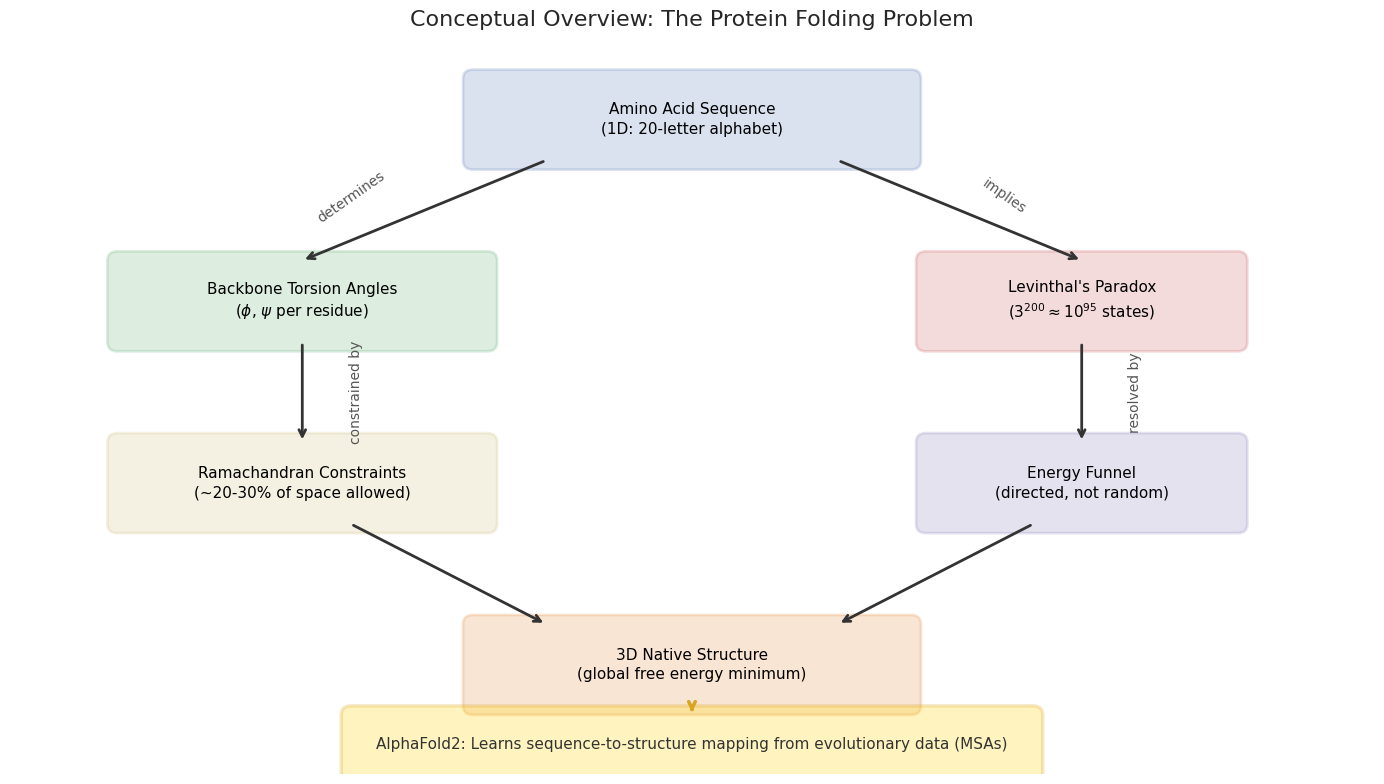

In [10]:
# Visual summary: concept map of the protein folding problem

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Conceptual Overview: The Protein Folding Problem', fontsize=16, pad=15)

# Define boxes: (x_center, y_center, width, height, text, color)
boxes = [
    (7.0, 7.2, 4.5, 0.9, 'Amino Acid Sequence\n(1D: 20-letter alphabet)', '#4C72B0'),
    (3.0, 5.2, 3.8, 0.9, 'Backbone Torsion Angles\n($\\phi$, $\\psi$ per residue)', '#55A868'),
    (11.0, 5.2, 3.2, 0.9, 'Levinthal\'s Paradox\n($3^{200} \\approx 10^{95}$ states)', '#C44E52'),
    (3.0, 3.2, 3.8, 0.9, 'Ramachandran Constraints\n(~20-30% of space allowed)', '#CCB974'),
    (11.0, 3.2, 3.2, 0.9, 'Energy Funnel\n(directed, not random)', '#8172B2'),
    (7.0, 1.2, 4.5, 0.9, '3D Native Structure\n(global free energy minimum)', '#E1812C'),
]

for (cx, cy, w, h, text, color) in boxes:
    rect = patches.FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                   boxstyle='round,pad=0.1',
                                   facecolor=color, alpha=0.2,
                                   edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(cx, cy, text, ha='center', va='center', fontsize=11,
            color='black', linespacing=1.4)

# Draw arrows between boxes
arrow_style = dict(arrowstyle='->', color='#333333', lw=2,
                   connectionstyle='arc3,rad=0.0')

# Sequence -> Torsion angles
ax.annotate('', xy=(3.0, 5.65), xytext=(5.5, 6.75),
            arrowprops=arrow_style)
ax.text(3.5, 6.35, 'determines', fontsize=10, color='#555555', rotation=35,
        ha='center', va='center')

# Sequence -> Levinthal
ax.annotate('', xy=(11.0, 5.65), xytext=(8.5, 6.75),
            arrowprops=arrow_style)
ax.text(10.2, 6.35, 'implies', fontsize=10, color='#555555', rotation=-35,
        ha='center', va='center')

# Torsion -> Ramachandran
ax.annotate('', xy=(3.0, 3.65), xytext=(3.0, 4.75),
            arrowprops=arrow_style)
ax.text(3.55, 4.2, 'constrained by', fontsize=10, color='#555555', rotation=90,
        ha='center', va='center')

# Levinthal -> Energy funnel
ax.annotate('', xy=(11.0, 3.65), xytext=(11.0, 4.75),
            arrowprops=arrow_style)
ax.text(11.55, 4.2, 'resolved by', fontsize=10, color='#555555', rotation=90,
        ha='center', va='center')

# Ramachandran -> Native structure
ax.annotate('', xy=(5.5, 1.65), xytext=(3.5, 2.75),
            arrowprops=arrow_style)

# Energy funnel -> Native structure
ax.annotate('', xy=(8.5, 1.65), xytext=(10.5, 2.75),
            arrowprops=arrow_style)

# Add the AlphaFold2 insight at the bottom
rect_af2 = patches.FancyBboxPatch((3.5, 0.0), 7.0, 0.65,
                                    boxstyle='round,pad=0.1',
                                    facecolor='gold', alpha=0.25,
                                    edgecolor='goldenrod', linewidth=2.5)
ax.add_patch(rect_af2)
ax.text(7.0, 0.32, 'AlphaFold2: Learns sequence-to-structure mapping from evolutionary data (MSAs)',
        ha='center', va='center', fontsize=11, color='#333333')

# Arrow from sequence down to AF2
ax.annotate('', xy=(7.0, 0.65), xytext=(7.0, 0.75),
            arrowprops=dict(arrowstyle='->', color='goldenrod', lw=2.5))

plt.tight_layout()
plt.show()